# Домашнее задание HW08-09: Регуляризация и оптимизация обучения нейросетей

## Вариант B: EMNIST (split="balanced")

В рамках ДЗ реализованы эксперименты по регуляризации (Dropout, BatchNorm, EarlyStopping) и оптимизации (анализ learning rate, сравнение оптимизаторов, weight decay) на датасете EMNIST balanced.

Структура ноутбука:
1. Импорты, настройки, создание папок для артефактов
2. Загрузка и подготовка данных EMNIST
3. Модель MLP и вспомогательные функции
4. Часть A (S08): Эксперименты с регуляризацией (E1-E4)
5. Часть B (S09): Эксперименты с оптимизацией (O1-O3)
6. Сохранение результатов и артефактов
7. Выводы

# 1. Импорты, настройки и создание структуры папок для артефактов

In [1]:
import os
import json
import csv
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Any, Tuple, Optional, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import transforms
from torchvision.datasets import EMNIST

# Создаем структуру папок для артефактов согласно заданию
ARTIFACTS_DIR = "homeworks/HW08-09/artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)  # exist_ok=True чтобы не было ошибки, если папка уже существует

print(f"Создана структура папок:")
print(f"  {ARTIFACTS_DIR}/")
print(f"  {FIGURES_DIR}/")

# Для Windows: num_workers=0 по умолчанию (чтобы избежать проблем с multiprocessing)
DEFAULT_NUM_WORKERS = 0

# Фиксируем seed для воспроизводимости результатов
def set_seed(seed: int = 42) -> None:
    """Фиксирует seed для всех генераторов случайных чисел."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    """Определяет доступное устройство (CUDA или CPU)."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Устанавливаем seed для всего ноутбука
GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
device = get_device()
print(f"\nИспользуемое устройство: {device}")

Создана структура папок:
  homeworks/HW08-09/artifacts/
  homeworks/HW08-09/artifacts/figures/

Используемое устройство: cpu


# 2. Загрузка и подготовка данных EMNIST balanced

В этом блоке:
- Загружаем датасет EMNIST со split="balanced" через torchvision
- Применяем нормализацию для приведения данных к диапазону [-1, 1]
- Создаем валидационную выборку (80% train, 20% val) с фиксированным seed
- Создаем DataLoader'ы для train, val и test
- Выполняем sanity check загруженных данных

## Выбор датасета

В данной работе используется датасет **EMNIST (Extended MNIST), split="balanced"** — расширенная версия MNIST, содержащая рукописные цифры и буквы латинского алфавита.

Особенности выбранного варианта:

* 47 классов (цифры + буквы),
* изображения размером 28×28 пикселей,
* 1 канал (grayscale),
* формат полностью совместим с MNIST.

По сравнению с MNIST, задача является более сложной, поскольку:

* классов больше,
* визуальные различия между некоторыми символами минимальны,
* это делает регуляризацию более значимой.

Поскольку используется MLP (а не CNN):

* изображения размером 28×28 преобразуются в вектор размерности 784 признака через `Flatten` внутри модели.

Дополнительно:

* используется `ToTensor()` для перевода изображений в тензоры PyTorch,
* применяется нормализация `(mean=0.5, std=0.5)` для стабилизации обучения.

---

In [2]:
def load_emnist_data(fast_mode: bool = False):
    """
    Загружает датасет EMNIST balanced.

    Args:
        fast_mode: если True, загружает только подмножество данных для быстрого тестирования

    Returns:
        ds_train_full: полный тренировочный датасет (до разбиения на train/val)
        ds_test: тестовый датасет
        input_shape: форма входных изображений (C, H, W)
        num_classes: количество классов
        dataset_name: название датасета
    """
    # Трансформации: тензор + нормализация в диапазон [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),  # преобразует в тензор и приводит к [0, 1]
        transforms.Normalize((0.5,), (0.5,))  # нормализует в [-1, 1]: (x - 0.5) / 0.5
    ])

    # Загружаем EMNIST balanced
    # root="./data" - данные сохранятся в папку data относительно текущей директории
    ds_train_full = EMNIST(
        root="./data",
        split="balanced",
        train=True,
        download=True,
        transform=transform
    )

    ds_test = EMNIST(
        root="./data",
        split="balanced",
        train=False,
        download=True,
        transform=transform
    )

    # Если fast_mode=True, берем подмножество данных для быстрого выполнения
    if fast_mode:
        # Для train берем первые 12000 образцов
        ds_train_full = Subset(ds_train_full, range(min(12000, len(ds_train_full))))
        # Для test берем первые 3000 образцов
        ds_test = Subset(ds_test, range(min(3000, len(ds_test))))
        print("Fast mode: используем подмножество данных")

    # Определяем форму входных данных и количество классов
    input_shape = (1, 28, 28)  # EMNIST: 28x28 grayscale
    num_classes = len(ds_train_full.dataset.classes) if hasattr(ds_train_full, 'dataset') else 47

    return ds_train_full, ds_test, input_shape, num_classes, "EMNIST balanced"

def split_train_val(ds_train_full, val_ratio: float = 0.2, seed: int = 42):
    """
    Разбивает тренировочный датасет на train и val с фиксированным seed.

    Args:
        ds_train_full: полный тренировочный датасет
        val_ratio: доля валидационной выборки
        seed: seed для воспроизводимости разбиения

    Returns:
        ds_train, ds_val: разделенные датасеты
    """
    n_total = len(ds_train_full)
    n_val = max(1, int(n_total * val_ratio))
    n_train = n_total - n_val

    # Используем генератор с фиксированным seed для воспроизводимости
    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=gen)

    print(f"Разбиение датасета: train={n_train} ({n_train/n_total:.1%}), val={n_val} ({n_val/n_total:.1%})")

    return ds_train, ds_val

def create_dataloaders(ds_train, ds_val, ds_test, batch_size: int = 128):
    """
    Создает DataLoader'ы для train, val и test.

    Args:
        ds_train, ds_val, ds_test: датасеты
        batch_size: размер батча

    Returns:
        train_loader, val_loader, test_loader
    """
    train_loader = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,  # перемешиваем только train
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()  # ускоряет передачу на GPU
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,  # не перемешиваем val и test
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader

# Загружаем данные
print("Загрузка данных EMNIST balanced...")
ds_train_full, ds_test, input_shape, num_classes, ds_name = load_emnist_data(fast_mode=False)
print(f"Датасет: {ds_name}")
print(f"Форма входных данных: {input_shape}")
print(f"Количество классов: {num_classes}")
print(f"Размер train (полный): {len(ds_train_full)}")
print(f"Размер test: {len(ds_test)}")

# Разбиваем train на train/val
ds_train, ds_val = split_train_val(ds_train_full, val_ratio=0.2, seed=GLOBAL_SEED)

# Создаем DataLoader'ы
BATCH_SIZE = 128
train_loader, val_loader, test_loader = create_dataloaders(
    ds_train, ds_val, ds_test, batch_size=BATCH_SIZE
)

# Sanity check: проверяем, что данные загрузились корректно
print("\nSanity check данных:")
x, y = next(iter(train_loader))
print(f"Форма батча x: {x.shape}")  # ожидаем [batch_size, 1, 28, 28]
print(f"Форма батча y: {y.shape}")  # ожидаем [batch_size]
print(f"Минимальное значение x: {x.min().item():.3f}")
print(f"Максимальное значение x: {x.max().item():.3f}")
print(f"Уникальные классы в батче: {torch.unique(y).tolist()}")

Загрузка данных EMNIST balanced...


100%|██████████| 562M/562M [00:09<00:00, 62.1MB/s]


Датасет: EMNIST balanced
Форма входных данных: (1, 28, 28)
Количество классов: 47
Размер train (полный): 112800
Размер test: 18800
Разбиение датасета: train=90240 (80.0%), val=22560 (20.0%)

Sanity check данных:
Форма батча x: torch.Size([128, 1, 28, 28])
Форма батча y: torch.Size([128])
Минимальное значение x: -1.000
Максимальное значение x: 1.000
Уникальные классы в батче: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]


# 3. Модель MLP и вспомогательные функции

В этом блоке:
- Реализуем класс MLP с поддержкой Dropout и BatchNorm
- Создаем функции для вычисления accuracy
- Реализуем функции train_one_epoch и evaluate
- Создаем функцию для визуализации и сохранения графиков
- Определяем функцию для логирования нормы градиента (понадобится в части B)

In [3]:
class MLP(nn.Module):
    """
    Многослойный перцептрон с поддержкой Dropout и BatchNorm.

    Архитектура:
    - Вход: Flatten (преобразует изображение в вектор)
    - Скрытые слои: Linear -> [BatchNorm] -> Activation -> [Dropout]
    - Выход: Linear (logits)
    """

    def __init__(
        self,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        """
        Args:
            input_shape: форма входного изображения (C, H, W)
            num_classes: количество классов для выхода
            hidden_sizes: список размеров скрытых слоев
            activation: функция активации ("relu", "tanh", "gelu")
            use_batchnorm: использовать ли BatchNorm после линейных слоев
            dropout: вероятность dropout (0 = не использовать)
        """
        super().__init__()
        c, h, w = input_shape
        in_features = c * h * w  # общее количество пикселей

        # Выбираем функцию активации
        if activation.lower() == "relu":
            act_layer = nn.ReLU
        elif activation.lower() == "tanh":
            act_layer = nn.Tanh
        elif activation.lower() == "gelu":
            act_layer = nn.GELU
        else:
            act_layer = nn.ReLU  # по умолчанию ReLU

        # Строим последовательность слоев
        layers: List[nn.Module] = [nn.Flatten()]  # первый слой - преобразование в вектор

        prev = in_features
        for i, hs in enumerate(hidden_sizes):
            # Линейный слой
            layers.append(nn.Linear(prev, hs))

            # BatchNorm (если включен) - ставим после Linear, до активации
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))

            # Активация
            layers.append(act_layer())

            # Dropout (если > 0) - ставим после активации
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev = hs

        # Выходной слой (без активации - CrossEntropyLoss включает Softmax)
        layers.append(nn.Linear(prev, num_classes))

        # Объединяем все слои в Sequential
        self.net = nn.Sequential(*layers)

        # Сохраняем параметры для возможности восстановления модели
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.hidden_sizes = hidden_sizes
        self.activation = activation
        self.use_batchnorm = use_batchnorm
        self.dropout = dropout

    def forward(self, x):
        """Прямой проход через сеть."""
        return self.net(x)

    def get_config(self) -> Dict[str, Any]:
        """Возвращает конфигурацию модели для сохранения."""
        return {
            "input_shape": self.input_shape,
            "num_classes": self.num_classes,
            "hidden_sizes": self.hidden_sizes,
            "activation": self.activation,
            "use_batchnorm": self.use_batchnorm,
            "dropout": self.dropout,
        }


def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    """
    Вычисляет accuracy по логитам модели.

    Args:
        logits: выход модели (batch_size, num_classes)
        y: истинные метки (batch_size)

    Returns:
        accuracy: доля правильных предсказаний
    """
    preds = logits.argmax(dim=1)  # выбираем класс с максимальным логитом
    return (preds == y).float().mean().item()


def grad_global_norm(parameters) -> float:
    """
    Вычисляет глобальную L2 норму градиентов.

    Args:
        parameters: параметры модели (model.parameters())

    Returns:
        grad_norm: sqrt(sum(p.grad.norm()^2 for p in parameters))
    """
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return math.sqrt(total_norm_sq)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
) -> Dict[str, float]:
    """
    Обучает модель одну эпоху.

    Args:
        model: модель для обучения
        loader: DataLoader с тренировочными данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство для вычислений
        max_grad_norm: максимальная норма градиента для clipping (None = без clipping)
        log_grad_norm: логировать ли норму градиента

    Returns:
        dict со средними значениями loss, accuracy и, опционально, нормы градиента
    """
    model.train()  # переводим модель в режим обучения
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    grad_norms_before = []
    grad_norms_after = []

    for x, y in loader:
        # Перемещаем данные на устройство
        x = x.to(device)
        y = y.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad(set_to_none=True)

        # Прямой проход
        logits = model(x)
        loss = criterion(logits, y)

        # Проверка на NaN (на всякий случай)
        if not torch.isfinite(loss):
            print(f"Предупреждение: loss = {loss.item()}, пропускаем батч")
            continue

        # Обратный проход
        loss.backward()

        # Логируем норму градиента ДО clipping
        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)

        # Gradient clipping (если задан)
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)

        # Обновляем веса
        optimizer.step()

        # Собираем статистику
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    # Усредняем метрики
    avg_loss = total_loss / max(1, n)
    avg_acc = total_acc / max(1, n)

    out = {"loss": float(avg_loss), "acc": float(avg_acc)}

    if log_grad_norm:
        out["grad_norm_before_mean"] = float(np.mean(grad_norms_before)) if grad_norms_before else None
        if max_grad_norm is not None:
            out["grad_norm_after_mean"] = float(np.mean(grad_norms_after)) if grad_norms_after else None

    return out


@torch.no_grad()  # декоратор отключает вычисление градиентов
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> Dict[str, float]:
    """
    Оценивает модель на валидационном или тестовом наборе.

    Args:
        model: модель для оценки
        loader: DataLoader с данными
        criterion: функция потерь
        device: устройство для вычислений

    Returns:
        dict со средними значениями loss и accuracy
    """
    model.eval()  # переводим модель в режим оценки
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            continue

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    return {"loss": float(total_loss / max(1, n)), "acc": float(total_acc / max(1, n))}


def plot_and_save_history(
    history: Dict[str, List[float]],
    title: str = "",
    filename: Optional[str] = None
):
    """
    Строит графики loss и accuracy по эпохам и сохраняет их.

    Args:
        history: словарь с историей обучения
        title: заголовок графиков
        filename: имя файла для сохранения (без пути)
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    # График loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss", marker='o')
    plt.plot(epochs, history["val_loss"], label="val_loss", marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc", marker='o')
    plt.plot(epochs, history["val_acc"], label="val_acc", marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Сохраняем график, если указано имя файла
    if filename:
        save_path = os.path.join(FIGURES_DIR, filename)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранен: {save_path}")

    plt.show()


def plot_lr_extremes(o1_history: Dict[str, List[float]], o2_history: Dict[str, List[float]]):
    """
    Строит график для демонстрации эффекта слишком большого и слишком маленького LR.

    Args:
        o1_history: история для эксперимента с большим LR
        o2_history: история для эксперимента с маленьким LR
    """
    plt.figure(figsize=(14, 6))

    # График loss
    plt.subplot(1, 2, 1)
    epochs1 = range(1, len(o1_history["val_loss"]) + 1)
    epochs2 = range(1, len(o2_history["val_loss"]) + 1)

    plt.plot(epochs1, o1_history["val_loss"], label="O1: LR too high", marker='o', color='red')
    plt.plot(epochs2, o2_history["val_loss"], label="O2: LR too low", marker='s', color='blue')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Влияние learning rate на сходимость (Loss)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs1, o1_history["val_acc"], label="O1: LR too high", marker='o', color='red')
    plt.plot(epochs2, o2_history["val_acc"], label="O2: LR too low", marker='s', color='blue')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Влияние learning rate на сходимость (Accuracy)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Сохраняем график
    save_path = os.path.join(FIGURES_DIR, "curves_lr_extremes.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"График сохранен: {save_path}")

    plt.show()

# 4. Часть A (S08): Эксперименты с регуляризацией

В этой части проводим 4 эксперимента для исследования эффекта регуляризации:

- **E1 (base)**: MLP с 3 скрытыми слоями, без Dropout и BatchNorm
- **E2 (Dropout)**: та же архитектура, но с Dropout (p=0.3)
- **E3 (BatchNorm)**: та же архитектура, но с BatchNorm
- **E4 (EarlyStopping)**: лучший из E2/E3 с EarlyStopping (patience=3)

Все эксперименты используют одинаковые гиперпараметры (кроме добавляемых техник) для корректного сравнения.

ЗАПУСК ЭКСПЕРИМЕНТОВ ЧАСТИ A (E1-E4)

=== Запуск эксперимента E1 ===
Конфигурация: hidden_sizes=[512, 256, 128], batchnorm=False, dropout=0.0
Оптимизатор: adam, lr=0.001, weight_decay=0.0
Разбиение датасета: train=90240 (80.0%), val=22560 (20.0%)
Эпоха 5/15: train_loss=0.4340, train_acc=0.8463, val_loss=0.5145, val_acc=0.8306
Эпоха 10/15: train_loss=0.3157, train_acc=0.8783, val_loss=0.4928, val_acc=0.8416
Эпоха 15/15: train_loss=0.2547, train_acc=0.8965, val_loss=0.5526, val_acc=0.8378
Эксперимент E1 завершен. Best val_acc: 0.8457 (эпоха 9), Test_acc: 0.8381

=== Запуск эксперимента E2 ===
Конфигурация: hidden_sizes=[512, 256, 128], batchnorm=False, dropout=0.3
Оптимизатор: adam, lr=0.001, weight_decay=0.0
Разбиение датасета: train=90240 (80.0%), val=22560 (20.0%)
Эпоха 5/15: train_loss=0.7513, train_acc=0.7590, val_loss=0.5513, val_acc=0.8191
Эпоха 10/15: train_loss=0.6521, train_acc=0.7874, val_loss=0.4991, val_acc=0.8325
Эпоха 15/15: train_loss=0.6031, train_acc=0.7983, val_loss=0.

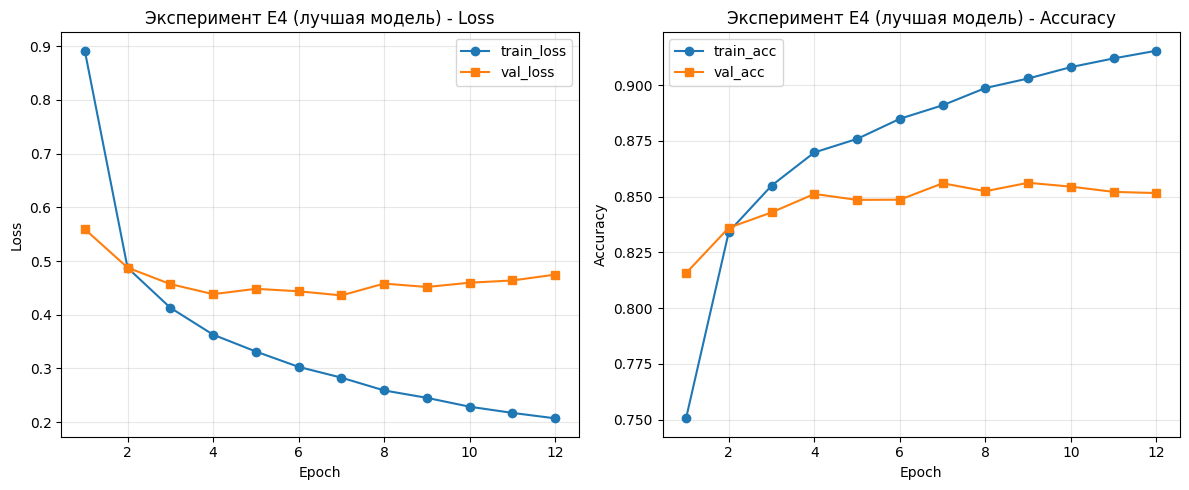

Эксперимент E4 завершен. Best val_acc: 0.8562 (эпоха 9), Test_acc: 0.8510


In [4]:
@dataclass
class ExperimentConfig:
    """Конфигурация эксперимента."""
    # Идентификация
    experiment_id: str  # E1, E2, E3, E4, O1, O2, O3

    # Параметры модели
    hidden_sizes: List[int]
    activation: str = "relu"
    use_batchnorm: bool = False
    dropout: float = 0.0

    # Параметры оптимизации
    optimizer: str = "adam"  # "adam" или "sgd"
    lr: float = 1e-3
    momentum: float = 0.0  # для SGD
    weight_decay: float = 0.0

    # Параметры обучения
    epochs: int = 15
    batch_size: int = 128

    # Ранняя остановка
    use_early_stopping: bool = False
    patience: int = 3

    # Gradient clipping (для части B)
    max_grad_norm: Optional[float] = None
    log_grad_norm: bool = False

    # Seed
    seed: int = 42


def create_optimizer(model: nn.Module, cfg: ExperimentConfig):
    """
    Создает оптимизатор согласно конфигурации.
    """
    if cfg.optimizer.lower() == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )
    elif cfg.optimizer.lower() == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=cfg.lr,
            momentum=cfg.momentum,
            weight_decay=cfg.weight_decay
        )
    else:
        raise ValueError(f"Unknown optimizer: {cfg.optimizer}")


def run_experiment(
    cfg: ExperimentConfig,
    ds_train_full,
    ds_test,
    input_shape,
    num_classes,
    device,
    save_best_model: bool = False
) -> Dict[str, Any]:
    """
    Запускает эксперимент с заданной конфигурацией.

    Args:
        cfg: конфигурация эксперимента
        ds_train_full: полный тренировочный датасет
        ds_test: тестовый датасет
        input_shape: форма входных данных
        num_classes: количество классов
        device: устройство для вычислений
        save_best_model: сохранять ли лучшую модель (для E4)

    Returns:
        dict с результатами эксперимента
    """
    # Фиксируем seed для воспроизводимости
    set_seed(cfg.seed)

    print(f"\n=== Запуск эксперимента {cfg.experiment_id} ===")
    print(f"Конфигурация: hidden_sizes={cfg.hidden_sizes}, "
          f"batchnorm={cfg.use_batchnorm}, dropout={cfg.dropout}")
    print(f"Оптимизатор: {cfg.optimizer}, lr={cfg.lr}, weight_decay={cfg.weight_decay}")

    # Создаем DataLoader'ы с текущим seed
    ds_train, ds_val = split_train_val(ds_train_full, val_ratio=0.2, seed=cfg.seed)
    train_loader, val_loader, test_loader = create_dataloaders(
        ds_train, ds_val, ds_test, batch_size=cfg.batch_size
    )

    # Создаем модель
    model = MLP(
        input_shape=input_shape,
        num_classes=num_classes,
        hidden_sizes=cfg.hidden_sizes,
        activation=cfg.activation,
        use_batchnorm=cfg.use_batchnorm,
        dropout=cfg.dropout,
    ).to(device)

    # Создаем оптимизатор и функцию потерь
    optimizer = create_optimizer(model, cfg)
    criterion = nn.CrossEntropyLoss()

    # Инициализируем историю обучения
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "lr": [],
        "grad_norm_before": [],
        "grad_norm_after": [],
    }

    # Для отслеживания лучшей модели
    best_val_acc = -1.0
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0

    # Обучаем модель
    for epoch in range(1, cfg.epochs + 1):
        # Обучаем одну эпоху
        train_out = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            max_grad_norm=cfg.max_grad_norm,
            log_grad_norm=cfg.log_grad_norm,
        )

        # Оцениваем на валидации
        val_out = evaluate(model, val_loader, criterion, device)

        # Сохраняем историю
        history["train_loss"].append(train_out["loss"])
        history["train_acc"].append(train_out["acc"])
        history["val_loss"].append(val_out["loss"])
        history["val_acc"].append(val_out["acc"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if cfg.log_grad_norm:
            history["grad_norm_before"].append(train_out.get("grad_norm_before_mean"))
            history["grad_norm_after"].append(train_out.get("grad_norm_after_mean"))

        # Проверяем, улучшилась ли валидационная точность
        if val_out["acc"] > best_val_acc:
            best_val_acc = val_out["acc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Логируем прогресс
        if epoch % 5 == 0 or epoch == cfg.epochs:
            print(f"Эпоха {epoch}/{cfg.epochs}: "
                  f"train_loss={train_out['loss']:.4f}, train_acc={train_out['acc']:.4f}, "
                  f"val_loss={val_out['loss']:.4f}, val_acc={val_out['acc']:.4f}")

        # Early stopping
        if cfg.use_early_stopping and epochs_without_improvement >= cfg.patience:
            print(f"Ранняя остановка на эпохе {epoch} (patience={cfg.patience})")
            break

    # Загружаем лучшую модель для финальной оценки
    if best_state is not None:
        model.load_state_dict(best_state)

    # Оцениваем на тесте (только для лучшей модели)
    test_out = evaluate(model, test_loader, criterion, device)

    # Сохраняем лучшую модель, если требуется
    if save_best_model and best_state is not None:
        model_path = os.path.join(ARTIFACTS_DIR, "best_model.pt")
        torch.save(best_state, model_path)
        print(f"Лучшая модель сохранена: {model_path}")

        # Сохраняем конфиг лучшей модели
        config_path = os.path.join(ARTIFACTS_DIR, "best_config.json")
        best_config = {
            "experiment_id": cfg.experiment_id,
            "model_config": model.get_config(),
            "optimizer": cfg.optimizer,
            "lr": cfg.lr,
            "momentum": cfg.momentum,
            "weight_decay": cfg.weight_decay,
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "test_acc": test_out["acc"],
            "seed": cfg.seed,
            "dataset": "EMNIST balanced"
        }
        with open(config_path, 'w') as f:
            json.dump(best_config, f, indent=2)
        print(f"Конфиг лучшей модели сохранен: {config_path}")

    # Строим и сохраняем график для E4
    if save_best_model:
        plot_and_save_history(
            history,
            title=f"Эксперимент {cfg.experiment_id} (лучшая модель)",
            filename="curves_best.png"
        )

    print(f"Эксперимент {cfg.experiment_id} завершен. "
          f"Best val_acc: {best_val_acc:.4f} (эпоха {best_epoch}), "
          f"Test_acc: {test_out['acc']:.4f}")

    return {
        "experiment_id": cfg.experiment_id,
        "config": cfg,
        "best_val_acc": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "test_acc": float(test_out["acc"]),
        "test_loss": float(test_out["loss"]),
        "history": history,
        "model_state_dict": best_state,
    }


# Определяем конфигурации для экспериментов E1-E4
# Базовая архитектура: 3 скрытых слоя
HIDDEN_SIZES = [512, 256, 128]  # достаточно большая сеть для демонстрации эффектов

# E1: Base (без регуляризации)
e1_config = ExperimentConfig(
    experiment_id="E1",
    hidden_sizes=HIDDEN_SIZES,
    use_batchnorm=False,
    dropout=0.0,
    optimizer="adam",
    lr=1e-3,
    epochs=15,
    seed=GLOBAL_SEED
)

# E2: Dropout
e2_config = ExperimentConfig(
    experiment_id="E2",
    hidden_sizes=HIDDEN_SIZES,
    use_batchnorm=False,
    dropout=0.3,  # Dropout с вероятностью 0.3
    optimizer="adam",
    lr=1e-3,
    epochs=15,
    seed=GLOBAL_SEED
)

# E3: BatchNorm
e3_config = ExperimentConfig(
    experiment_id="E3",
    hidden_sizes=HIDDEN_SIZES,
    use_batchnorm=True,  # Включаем BatchNorm
    dropout=0.0,
    optimizer="adam",
    lr=1e-3,
    epochs=15,
    seed=GLOBAL_SEED
)

# E4: EarlyStopping (на лучшей из E2/E3)
# Сначала определим, что лучше: Dropout или BatchNorm
# Но для этого нужно запустить эксперименты и сравнить
# Пока создадим конфигурацию (будем использовать ту, что покажет лучший результат)

print("=" * 60)
print("ЗАПУСК ЭКСПЕРИМЕНТОВ ЧАСТИ A (E1-E4)")
print("=" * 60)

# Запускаем E1
e1_result = run_experiment(e1_config, ds_train_full, ds_test, input_shape, num_classes, device)

# Запускаем E2
e2_result = run_experiment(e2_config, ds_train_full, ds_test, input_shape, num_classes, device)

# Запускаем E3
e3_result = run_experiment(e3_config, ds_train_full, ds_test, input_shape, num_classes, device)

# Сравниваем E2 и E3, выбираем лучший для E4
if e2_result["best_val_acc"] >= e3_result["best_val_acc"]:
    print(f"\nE2 (Dropout) показал лучший результат: {e2_result['best_val_acc']:.4f} vs E3: {e3_result['best_val_acc']:.4f}")
    best_config_for_e4 = e2_config
else:
    print(f"\nE3 (BatchNorm) показал лучший результат: {e3_result['best_val_acc']:.4f} vs E2: {e2_result['best_val_acc']:.4f}")
    best_config_for_e4 = e3_config

# Создаем конфигурацию для E4 с early stopping
e4_config = ExperimentConfig(
    experiment_id="E4",
    hidden_sizes=best_config_for_e4.hidden_sizes,
    use_batchnorm=best_config_for_e4.use_batchnorm,
    dropout=best_config_for_e4.dropout,
    optimizer=best_config_for_e4.optimizer,
    lr=best_config_for_e4.lr,
    epochs=30,  # Больше эпох для возможности ранней остановки
    use_early_stopping=True,
    patience=3,
    seed=GLOBAL_SEED
)

# Запускаем E4 (лучшая модель, будет сохранена)
e4_result = run_experiment(
    e4_config, ds_train_full, ds_test, input_shape, num_classes, device,
    save_best_model=True  # Сохраняем как лучшую модель домашки
)

# 5. Часть B (S09): Эксперименты с оптимизацией

В этой части исследуем влияние learning rate и оптимизаторов:

- **O1 (LR слишком большой)**: Adam с lr=1e-1 (слишком высокий)
- **O2 (LR слишком маленький)**: Adam с lr=1e-5 (слишком низкий)
- **O3 (SGD + momentum + weight decay)**: SGD с momentum=0.9 и weight_decay=1e-4

Для всех экспериментов используем ту же архитектуру, что и в лучшей модели E4.


ЗАПУСК ЭКСПЕРИМЕНТОВ ЧАСТИ B (O1-O3)

Архитектура для экспериментов O1-O3 (как в E4):
  hidden_sizes: [512, 256, 128]
  use_batchnorm: True
  dropout: 0.0

--- Запуск O1: Слишком большой learning rate (1e-1) ---

=== Запуск эксперимента O1 ===
Конфигурация: hidden_sizes=[512, 256, 128], batchnorm=True, dropout=0.0
Оптимизатор: adam, lr=0.1, weight_decay=0.0
Разбиение датасета: train=90240 (80.0%), val=22560 (20.0%)
Эпоха 5/8: train_loss=0.5559, train_acc=0.8130, val_loss=0.6114, val_acc=0.8060
Эпоха 8/8: train_loss=0.4940, train_acc=0.8307, val_loss=0.5565, val_acc=0.8236
Эксперимент O1 завершен. Best val_acc: 0.8236 (эпоха 8), Test_acc: 0.8257

--- Запуск O2: Слишком маленький learning rate (1e-5) ---

=== Запуск эксперимента O2 ===
Конфигурация: hidden_sizes=[512, 256, 128], batchnorm=True, dropout=0.0
Оптимизатор: adam, lr=1e-05, weight_decay=0.0
Разбиение датасета: train=90240 (80.0%), val=22560 (20.0%)
Эпоха 5/8: train_loss=1.8061, train_acc=0.6714, val_loss=1.7038, val_acc=0.682

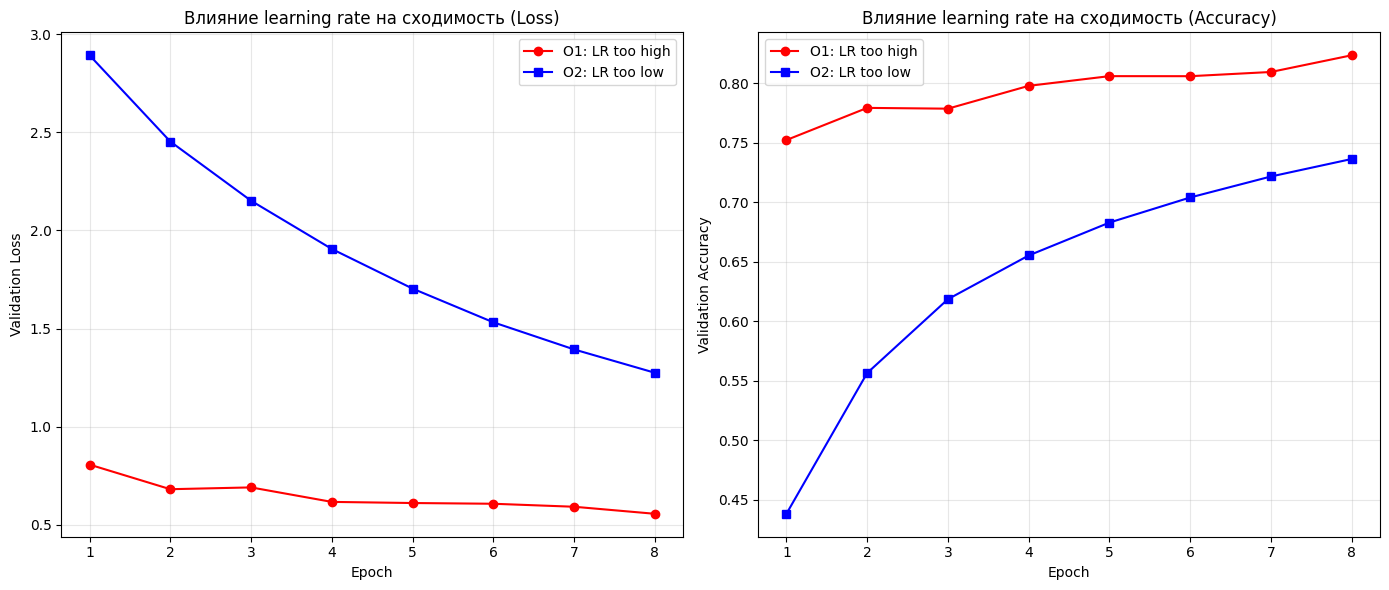

График сохранен: homeworks/HW08-09/artifacts/figures/curves_O3.png


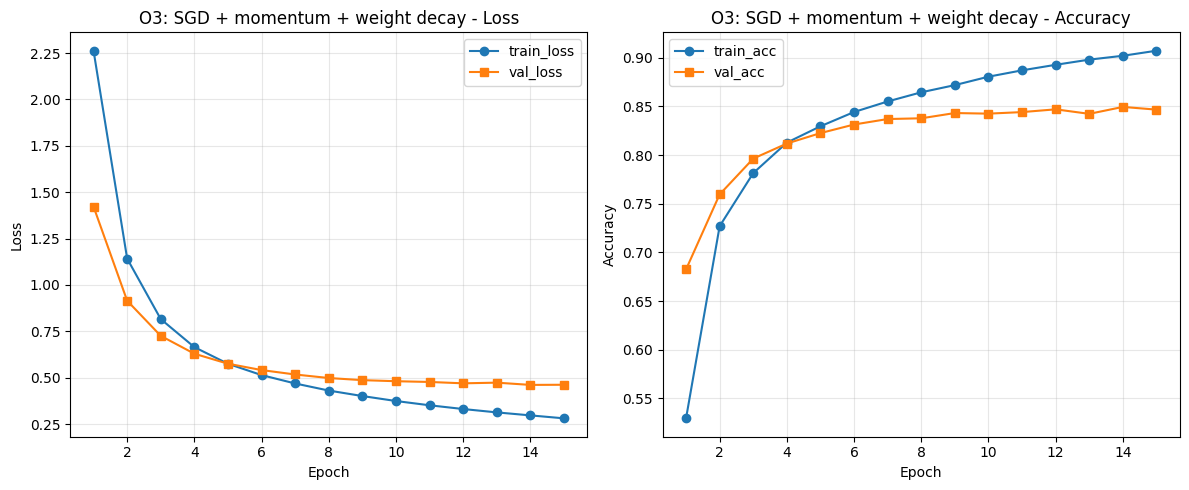

In [5]:
print("\n" + "=" * 60)
print("ЗАПУСК ЭКСПЕРИМЕНТОВ ЧАСТИ B (O1-O3)")
print("=" * 60)

# Используем ту же архитектуру, что и в лучшей модели E4
# Получаем параметры из best_config_for_e4
best_arch_config = {
    "hidden_sizes": best_config_for_e4.hidden_sizes,
    "use_batchnorm": best_config_for_e4.use_batchnorm,
    "dropout": best_config_for_e4.dropout,
}

print(f"\nАрхитектура для экспериментов O1-O3 (как в E4):")
print(f"  hidden_sizes: {best_arch_config['hidden_sizes']}")
print(f"  use_batchnorm: {best_arch_config['use_batchnorm']}")
print(f"  dropout: {best_arch_config['dropout']}")

# O1: Слишком большой learning rate
o1_config = ExperimentConfig(
    experiment_id="O1",
    hidden_sizes=best_arch_config['hidden_sizes'],
    use_batchnorm=best_arch_config['use_batchnorm'],
    dropout=best_arch_config['dropout'],
    optimizer="adam",
    lr=1e-1,  # Слишком большой LR
    epochs=8,  # Меньше эпох, т.к. проблема видна быстро
    seed=GLOBAL_SEED + 1  # Другой seed для разнообразия
)

# O2: Слишком маленький learning rate
o2_config = ExperimentConfig(
    experiment_id="O2",
    hidden_sizes=best_arch_config['hidden_sizes'],
    use_batchnorm=best_arch_config['use_batchnorm'],
    dropout=best_arch_config['dropout'],
    optimizer="adam",
    lr=1e-5,  # Слишком маленький LR
    epochs=8,
    seed=GLOBAL_SEED + 2
)

# O3: SGD + momentum + weight decay
o3_config = ExperimentConfig(
    experiment_id="O3",
    hidden_sizes=best_arch_config['hidden_sizes'],
    use_batchnorm=best_arch_config['use_batchnorm'],
    dropout=best_arch_config['dropout'],
    optimizer="sgd",
    lr=1e-3,  # Разумный LR для SGD
    momentum=0.9,
    weight_decay=1e-4,
    epochs=15,  # Больше эпох для SGD
    seed=GLOBAL_SEED + 3
)

# Запускаем эксперименты
print("\n--- Запуск O1: Слишком большой learning rate (1e-1) ---")
o1_result = run_experiment(o1_config, ds_train_full, ds_test, input_shape, num_classes, device)

print("\n--- Запуск O2: Слишком маленький learning rate (1e-5) ---")
o2_result = run_experiment(o2_config, ds_train_full, ds_test, input_shape, num_classes, device)

print("\n--- Запуск O3: SGD + momentum + weight decay ---")
o3_result = run_experiment(o3_config, ds_train_full, ds_test, input_shape, num_classes, device)

# Визуализируем эффект экстремальных learning rate
print("\n--- Визуализация эффекта экстремальных learning rate ---")
plot_lr_extremes(o1_result["history"], o2_result["history"])

# Для O3 тоже построим отдельный график
plot_and_save_history(
    o3_result["history"],
    title="O3: SGD + momentum + weight decay",
    filename="curves_O3.png"
)

# 6. Сохранение результатов экспериментов в runs.csv

В этом блоке собираем результаты всех экспериментов (E1-E4, O1-O3) и сохраняем их в таблицу runs.csv

In [7]:
def save_results_to_csv(experiment_results: List[Dict[str, Any]], filename: str = "runs.csv"):
    """
    Сохраняет результаты экспериментов в CSV файл.

    Args:
        experiment_results: список результатов экспериментов
        filename: имя файла для сохранения
    """
    csv_path = os.path.join(ARTIFACTS_DIR, filename)

    # Подготавливаем данные для CSV
    rows = []
    for result in experiment_results:
        cfg = result["config"]

        # Формируем строку с описанием модели
        model_summary = (f"hidden={cfg.hidden_sizes}, "
                        f"batchnorm={cfg.use_batchnorm}, "
                        f"dropout={cfg.dropout}")

        row = {
            "experiment_id": cfg.experiment_id,
            "dataset": "EMNIST balanced",
            "seed": cfg.seed,
            "model_summary": model_summary,
            "optimizer": cfg.optimizer,
            "lr": cfg.lr,
            "momentum": cfg.momentum if cfg.optimizer == "sgd" else "",
            "weight_decay": cfg.weight_decay,
            "epochs_trained": len(result["history"]["train_loss"]),  # фактическое число эпох
            "best_val_accuracy": f"{result['best_val_acc']:.6f}",
            "best_val_loss": f"{min(result['history']['val_loss']):.6f}",
            "test_accuracy": f"{result['test_acc']:.6f}",
            "test_loss": f"{result['test_loss']:.6f}",
        }
        rows.append(row)

    # Записываем в CSV
    with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
        if rows:
            fieldnames = rows[0].keys()
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

    print(f"Результаты сохранены в {csv_path}")

    # Выводим таблицу для наглядности
    print("\n" + "=" * 100)
    print("СВОДКА РЕЗУЛЬТАТОВ ВСЕХ ЭКСПЕРИМЕНТОВ")
    print("=" * 100)

    # Заголовок таблицы
    header = f"{'ID':<5} {'Optimizer':<10} {'LR':<10} {'Momentum':<8} {'WD':<8} {'Epochs':<8} {'Val Acc':<10} {'Test Acc':<10}"
    print(header)
    print("-" * len(header))

    # Строки таблицы
    for row in rows:
        print(f"{row['experiment_id']:<5} "
              f"{row['optimizer']:<10} "
              f"{row['lr']:<10} "
              f"{str(row['momentum']):<8} "
              f"{row['weight_decay']:<8} "
              f"{row['epochs_trained']:<8} "
              f"{float(row['best_val_accuracy']):<10.4f} "
              f"{float(row['test_accuracy']):<10.4f}")

    print("=" * 100)

# Собираем все результаты экспериментов
all_results = [
    e1_result, e2_result, e3_result, e4_result,
    o1_result, o2_result, o3_result
]

# Сохраняем в CSV
save_results_to_csv(all_results)

Результаты сохранены в homeworks/HW08-09/artifacts/runs.csv

СВОДКА РЕЗУЛЬТАТОВ ВСЕХ ЭКСПЕРИМЕНТОВ
ID    Optimizer  LR         Momentum WD       Epochs   Val Acc    Test Acc  
----------------------------------------------------------------------------
E1    adam       0.001               0.0      15       0.8457     0.8381    
E2    adam       0.001               0.0      15       0.8385     0.8369    
E3    adam       0.001               0.0      15       0.8563     0.8504    
E4    adam       0.001               0.0      12       0.8562     0.8510    
O1    adam       0.1                 0.0      8        0.8236     0.8257    
O2    adam       1e-05               0.0      8        0.7364     0.7345    
O3    sgd        0.001      0.9      0.0001   15       0.8495     0.8434    
